# Preliminaries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

## Data Loading

In [5]:
# =========================================================
# LOAD PREDICTIONS
# =========================================================

predictions = pd.read_csv("predictions/pm100/predictions_s.csv")

max_runtime = 86400
normalization = max_runtime / 100

errors_df = pd.DataFrame({
    "job_id": predictions["job_id"],
    "err_user": (predictions["pred_runtime_user"] - predictions["gt_runtime"]) / normalization,
    "err_heuristic": (predictions["pred_runtime_heuristic"] - predictions["gt_runtime"]) / normalization,
    "err_dt": (predictions["pred_runtime_dt"] - predictions["gt_runtime"]) / normalization,
    "err_rnp": (predictions["pred_runtime_rnp"] - predictions["gt_runtime"]) / normalization,
    "err_knn": (predictions["pred_runtime_knn"] - predictions["gt_runtime"]) / normalization,
    "err_llm": (predictions["pred_runtime_llm"] - predictions["gt_runtime"]) / normalization
})

## Helpers

In [6]:
def load_swf(filepath, sim_start_time):
    df = pd.read_csv(filepath, sep=';')

    # Convert timestamps to seconds from simulation start
    df["start_time"] = pd.to_datetime(df["start_time"]).astype("int64") // 10**9
    df["end_time"] = pd.to_datetime(df["end_time"]).astype("int64") // 10**9

    df["start_time"] -= sim_start_time
    df["end_time"] -= sim_start_time

    diff = min(df["start_time"])
    
    df["end_time"] -= diff
    df["start_time"] -= diff
    
    return df

In [7]:
def assign_job_classes(df, runtime_col="rtime", nodes_col="nodes"):

    df = df.copy()
    
    # --- Duration classification
    def duration_class(runtime):
        if 1 <= runtime < 300:
            return "Short"
        elif 300 <= runtime < 7200:
            return "Medium"
        elif 7200 <= runtime <= 86400:
            return "Long"
        else:
            return None

    # --- Size classification
    def size_class(nodes):
        if 1 <= nodes < 980/200:
            return "Small"
        elif 980/200 <= nodes < 980/100*3:
            return "Medium"
        elif 980/100*3 <= nodes <= 980:
            return "Large"
        else:
            return None

    # Apply classifications
    df["size_class"] = df[nodes_col].apply(size_class)
    df["duration_class"] = df[runtime_col].apply(duration_class)

    return df

## Functions: Metrics

In [8]:
TOTAL_NODES = 980

def compute_system_metrics(df, df_classes):
    df = df.copy()

    # -----------------------
    # 1. PREPROCESSING
    # -----------------------
    df['nodes'] = df['nodes'].astype(str).str.replace(r'^(\d+).*', r'\1', regex=True).astype(int)

    # Merge duration_class
    df = df.merge(df_classes[['job_id', 'duration_class']], on='job_id', how='left')

    # -----------------------
    # 2. UTILIZATION EVENTS
    # -----------------------
    metrics_events = []
    for _, row in df.iterrows():
        metrics_events.append((row["start_time"], row["nodes"]))
        metrics_events.append((row["end_time"], -row["nodes"]))

    metrics_df = pd.DataFrame(metrics_events, columns=['time', 'delta'])
    metrics_df = metrics_df.groupby('time')['delta'].sum().reset_index()
    metrics_df = metrics_df.sort_values('time')

    metrics_df['current_nodes'] = metrics_df['delta'].cumsum()
    metrics_df['utilization'] = metrics_df['current_nodes'] / TOTAL_NODES

    # -----------------------
    # 3. METRIC EVENTS (START ONLY)
    # -----------------------
    metric_events = df[['start_time', 'wtime', 'slowdown', 'duration_class']].copy()
    metric_events = metric_events.sort_values('start_time')

    # Aggregate per time
    base_agg = metric_events.groupby('start_time').agg({
        'wtime': 'sum',
        'slowdown': 'sum',
        'duration_class': 'count'
    }).rename(columns={'duration_class': 'job_count'})

    # Per-class counts (pivot)
    class_counts = (
        metric_events
        .groupby(['start_time', 'duration_class'])
        .size()
        .unstack(fill_value=0)
    )

    # Merge
    metric_events = base_agg.join(class_counts, how='left').fillna(0).reset_index()

    # -----------------------
    # 4. CUMULATIVE METRICS
    # -----------------------
    metric_events = metric_events.sort_values('start_time')

    # Total cumulative
    metric_events['cum_jobs'] = metric_events['job_count'].cumsum()
    metric_events['cum_wtime'] = metric_events['wtime'].cumsum()
    metric_events['cum_slowdown'] = metric_events['slowdown'].cumsum()

    metric_events['avg_wtime'] = metric_events['cum_wtime'] / metric_events['cum_jobs']
    metric_events['avg_slowdown'] = metric_events['cum_slowdown'] / metric_events['cum_jobs']

    # Per-class cumulative counts
    # duration_classes = ["Small-Short", "Small-Long", "Big-Short", "Big-Long"]
    duration_classes = ["Very-Short", "Short", "Medium", "Long", "Very-Long"]

    for cls in duration_classes:
        if cls not in metric_events.columns:
            metric_events[cls] = 0
        metric_events[f"cum_{cls}"] = metric_events[cls].cumsum()

    # -----------------------
    # 5. TIME SERIES ALIGNMENT
    # -----------------------
    metrics_df['time'] = metrics_df['time'].astype(int)
    metrics_df = metrics_df.set_index('time')

    metric_events['start_time'] = metric_events['start_time'].astype(int)
    metric_events = metric_events.set_index('start_time')

    t_min = min(metrics_df.index.min(), metric_events.index.min())
    t_max = max(metrics_df.index.max(), metric_events.index.max())
    full_range = np.arange(t_min, t_max + 1)

    # Reindex all series
    metrics_series = metrics_df['utilization'].reindex(full_range)
    wtime_series = metric_events['avg_wtime'].reindex(full_range)
    slowdown_series = metric_events['avg_slowdown'].reindex(full_range)
    jobs_series = metric_events['cum_jobs'].reindex(full_range)

    # Per-class series
    class_series = {
        cls: metric_events[f"cum_{cls}"].reindex(full_range)
        for cls in duration_classes
    }

    # Fill forward
    metrics_series = metrics_series.ffill().fillna(0)
    wtime_series = wtime_series.ffill().fillna(0)
    slowdown_series = slowdown_series.ffill().fillna(0)
    jobs_series = jobs_series.ffill().fillna(0)

    for cls in duration_classes:
        class_series[cls] = class_series[cls].ffill().fillna(0)

    # -----------------------
    # 6. OUTPUT
    # -----------------------
    result = {
        "time": full_range,
        "system_utilization": metrics_series.values,
        "average_utilization": metrics_series.mean(),
        "avg_waiting_time": wtime_series.values,
        "avg_slowdown": slowdown_series.values,
        "cum_jobs": jobs_series.values
    }

    # Add per-class outputs
    for cls in duration_classes:
        result[f"cum_jobs_{cls}"] = class_series[cls].values

    return result

In [19]:
def compute_ordering_metrics(
    df,
    predictions,
    pred_col="pred_runtime_llm",
    total_nodes=980,
    saturation_threshold=0.90,
    short_jobs_threshold=300.0,
    n_bins=10,
    alpha=1.0,
    gamma=0.75,
):

    jobs = df.copy()

    jobs["nodes"] = (
        jobs["nodes"]
        .astype(str)
        .str.replace(r"^(\d+).*", r"\1", regex=True)
        .astype(int)
    )

    jobs = jobs.merge(
        predictions[["job_id", "gt_runtime", pred_col]],
        on="job_id",
        how="left",
    )

    jobs = jobs.rename(
        columns={
            "gt_runtime": "true_runtime",
            pred_col: "pred_runtime",
        }
    )

    # --------------------------------------------------
    # Duration classes
    # --------------------------------------------------
    def duration_class(runtime):
        if runtime < short_jobs_threshold:
            return "Short"
        elif runtime < 24 * short_jobs_threshold:
            return "Medium"
        else:
            return "Long"

    jobs["duration_class"] = jobs["true_runtime"].apply(duration_class)

    runtime_median = np.median(jobs["true_runtime"])
    # if runtime_median == 0 or np.isnan(runtime_median):
    #    runtime_median = 50.0  
    
    total_runtime_mass = jobs["true_runtime"].sum()

    # --------------------------------------------------
    # Utilization curve
    # --------------------------------------------------
    util_events = []

    for _, row in jobs.iterrows():
        util_events.append((row["start_time"], row["nodes"]))
        util_events.append((row["end_time"], -row["nodes"]))

    util_df = pd.DataFrame(util_events, columns=["time", "delta"])

    util_df = (
        util_df.groupby("time")["delta"]
        .sum()
        .reset_index()
        .sort_values("time")
    )

    util_df["active_nodes"] = util_df["delta"].cumsum()
    util_df["util"] = util_df["active_nodes"] / total_nodes

    dispatch_times = np.sort(jobs["start_time"].unique())

    dispatch_df = pd.DataFrame({"time": dispatch_times})

    util_mapped = pd.merge_asof(
        dispatch_df,
        util_df[["time", "util"]],
        on="time",
        direction="backward",
    )

    util_mapping = (
        util_mapped.set_index("time")["util"].to_dict()
    )

    # --------------------------------------------------
    # Event accumulators
    # --------------------------------------------------
    ID_events = []

    ID_H_events = []
    ID_P_events = []

    ID_AWT_events = []
    ID_ASD_events = []

    QDS_AWT_events = []
    QDS_ASD_events = []

    # --------------------------------------------------
    # Main loop
    # --------------------------------------------------
    for t in dispatch_times:

        U_t = util_mapping.get(t, 0.0)

        if U_t < saturation_threshold:
            continue

        queue = jobs[
            (jobs["submit_time"] <= t)
            & (jobs["start_time"] > t)
        ].copy()

        n_t = len(queue)

        if n_t < 2:
            continue

        # --------------------------------------------------
        # Queue pressure P_t
        # --------------------------------------------------
        queue_runtime_mass = queue["true_runtime"].sum()

        P_t = np.log1p(n_t) * (
            1.0
            + queue_runtime_mass / total_runtime_mass
        )

        # --------------------------------------------------
        # Pairwise matrices
        # --------------------------------------------------
        arr = queue[
            ["true_runtime", "pred_runtime", "nodes"]
        ].to_numpy()

        r = arr[:, 0]
        p = arr[:, 1]
        nodes = arr[:, 2]

        r_i = r[:, np.newaxis]
        r_j = r[np.newaxis, :]

        p_i = p[:, np.newaxis]
        p_j = p[np.newaxis, :]

        nodes_j = nodes[np.newaxis, :]

        valid_pairs = r_i < r_j
        inversions = valid_pairs & (p_i > p_j)

        ID_t = 0.0
        ID_H_t = 0.0
        ID_P_t = 0.0
        ID_AWT_t = 0.0
        ID_ASD_t = 0.0

        if np.any(inversions):

            long_r = r_j
            short_r = r_i
            long_nodes = nodes_j

            # ------------------------------------------
            # Base inversion weight w(i,j,t)
            # ------------------------------------------
            runtime_gap = (
                (long_r - short_r)
                / long_r
            )

            size_weight = (
                long_nodes / total_nodes
            )

            duration_weight = (
                1.0
                + np.log1p(
                    long_r
                    / short_jobs_threshold
                )
            )

            w_matrix = (
                U_t
                * size_weight
                * duration_weight
                * runtime_gap
            )

            # ------------------------------------------
            # H_j
            # ------------------------------------------
            
            H_j = (
                np.maximum(
                    long_r / runtime_median,
                    1.0,
                )
            ) ** gamma

            # ------------------------------------------
            # S_i
            # ------------------------------------------
            S_i = (
                1.0
                / (
                    1.0
                    + np.log1p(
                        short_r
                        / short_jobs_threshold
                    )
                )
            )

            # ------------------------------------------
            # Ablation components
            # ------------------------------------------
            ID_t = float(
                np.sum(
                    w_matrix[inversions]
                )
            )

            ID_H_t = float(
                np.sum(
                    (
                        w_matrix
                        * H_j
                    )[inversions]
                )
            )

            ID_P_t = float(
                np.sum(
                    (
                        w_matrix
                        * P_t
                    )[inversions]
                )
            )

            ID_AWT_t = float(
                np.sum(
                    (
                        w_matrix
                        * H_j
                        * P_t
                    )[inversions]
                )
            )

            ID_ASD_t = float(
                np.sum(
                    (
                        w_matrix
                        * S_i
                    )[inversions]
                )
            )

        ID_events.append(ID_t)

        ID_H_events.append(ID_H_t)
        ID_P_events.append(ID_P_t)

        ID_AWT_events.append(ID_AWT_t)
        ID_ASD_events.append(ID_ASD_t)

        # --------------------------------------------------
        # Queue Distribution Scores
        # --------------------------------------------------
        queue = (
            queue
            .sort_values("pred_runtime")
            .reset_index(drop=True)
        )

        queue["bin"] = pd.cut(
            np.arange(len(queue)),
            bins=n_bins,
            labels=False,
            include_lowest=True,
        )

        QDS_AWT_t = 0.0
        QDS_ASD_t = 0.0

        for b in range(n_bins):

            bin_jobs = queue[
                queue["bin"] == b
            ]

            if len(bin_jobs) == 0:
                continue

            p_bin = b / (n_bins - 1)

            n_short = (
                bin_jobs["duration_class"]
                == "Short"
            ).sum()

            n_medium = (
                bin_jobs["duration_class"]
                == "Medium"
            ).sum()

            n_long = (
                bin_jobs["duration_class"]
                == "Long"
            ).sum()

            QDS_AWT_t += (
                n_short * p_bin
                + 0.5 * n_medium * p_bin
                + n_long * (1 - p_bin)
            )

            QDS_ASD_t += (
                3.0 * n_short * p_bin
            )

        QDS_AWT_events.append(
            U_t * QDS_AWT_t
        )

        QDS_ASD_events.append(
            U_t * QDS_ASD_t
        )

    # --------------------------------------------------
    # Reduction
    # --------------------------------------------------
    ID = np.sum(ID_events)

    ID_H = np.sum(ID_H_events)
    ID_P = np.sum(ID_P_events)

    ID_AWT = np.sum(ID_AWT_events)
    ID_ASD = np.sum(ID_ASD_events)

    QDS_AWT = (
        np.mean(QDS_AWT_events)
        if QDS_AWT_events
        else 0.0
    )

    QDS_ASD = (
        np.mean(QDS_ASD_events)
        if QDS_ASD_events
        else 0.0
    )

    OD_AWT = (
        ID_AWT
        * (1 + alpha * QDS_AWT)
    )

    OD_ASD = (
        ID_ASD
        * (1 + alpha * QDS_ASD)
    )

    return {

        # Ablation hierarchy
        "ID": ID,
        "ID_H": ID_H,
        "ID_P": ID_P,
        "ID_AWT": ID_AWT,
        "ID_ASD": ID_ASD,

        # Queue scores
        "QDS_AWT": QDS_AWT,
        "QDS_ASD": QDS_ASD,

        # Final metrics
        "OD_AWT": OD_AWT,
        "OD_ASD": OD_ASD,

        # Event traces (optional)
        "ID_events": np.array(ID_events),
        "ID_H_events": np.array(ID_H_events),
        "ID_P_events": np.array(ID_P_events),
        "ID_AWT_events": np.array(ID_AWT_events),
        "ID_ASD_events": np.array(ID_ASD_events),
    }

In [10]:
def count_jobs_in_window(err_df, t_start, t_end, methods=None):
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    # duration_classes = ["Small-Short", "Small-Long", "Big-Short", "Big-Long"]
    duration_classes = ["Short", "Medium", "Long"]
    
    # Default: all methods
    if methods is None:
        methods = list(method_map.keys())

    results = {}

    for method in methods:
        suffix = method_map.get(method)
        st_col = f"st_{suffix}"

        if st_col not in err_df.columns:
            print(f"[WARNING] Column {st_col} not found, skipping {method}")
            continue

        counts = {}

        for cls in duration_classes:
            subset = err_df[err_df["duration_class"] == cls]

            mask = (subset[st_col] >= t_start) & (subset[st_col] <= t_end)
            counts[cls] = mask.sum()

        results[method] = counts

    # -----------------------
    # PRINT
    # -----------------------
    print(f"\nTime window: [{t_start/60}, {t_end/60}]\n")

    for method, counts in results.items():
        total = sum(counts.values())
        print(f"{method}:")
        for cls in duration_classes:
            print(f"  {cls:12s}: {counts[cls]:4d}")
        print(f"  {'TOTAL':12s}: {total:4d}")
        print()

In [11]:
def print_utilization_in_window(data, start, end):
    """
    Filters and prints system_utilization based on a time range.
    """
    # Create a boolean mask where time is within the bounds
    time_array = data['time']
    mask = (time_array >= start) & (time_array <= end)
    
    # Apply the mask to the utilization array
    windowed_util = data['system_utilization'][mask]
    
    if windowed_util.size > 0:
        print(f"System Utilization from time {start} to {end}:")
        print(windowed_util)
    else:
        print(f"No data found for the time range: {start} to {end}")

## Plots

In [14]:
def plot_metrics(metrics_list, labels, title="System Utilization"):
    plt.figure(figsize=(12, 4))
    
    for sim_result, label in zip(metrics_list, labels):
        plt.plot(
            sim_result["time"],
            sim_result["system_utilization"],
            label=label
        )
    
    plt.xlabel("Time (seconds)")
    plt.ylabel("Utilization (0–1)")
    plt.title(title)
    
    plt.legend()
    plt.grid()
    plt.show()

def plot_metrics_window(metrics_list, labels, t_start=0, t_end=301, v_lines=[], title="System Utilization", image_path=''):
    plt.figure(figsize=(12, 4))
    
    for sim_result, label in zip(metrics_list, labels):
        # Convert to numpy arrays for masking capability
        time = np.array(sim_result["time"])
        util = np.array(sim_result["system_utilization"]*100)
        
        # Create the mask: True if time is within our range
        mask = (time >= t_start) & (time <= t_end)
        
        # Apply the mask to both arrays
        plt.plot(time[mask], util[mask], label=label)
    
    ticks = np.arange(t_start, t_end, 300)
    plt.xlim(0, max(ticks))
    plt.ylim(0, 100)
    for line in v_lines:
        plt.axvline(line, linestyle="--", alpha=0.5, color='black')
        plt.text(line + 20, 0.02, f'{line} s',
                 transform=plt.gca().get_xaxis_transform(),
                 ha='left',
                 va='bottom',
                 fontsize=9,
                 alpha=0.7)
        
    plt.xticks(ticks=ticks, labels=(ticks / 60).astype(int))
    plt.xlabel("Start Time (minutes)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()


def plot_metrics_with_errors(
    metrics,
    err_df,
    labels,
    methods_to_plot=None,
    t_start=0,
    t_end=3900,
    title="Scheduling Metrics vs Errors",
    image_path=''
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    # -----------------------
    # FIGURE SETUP
    # -----------------------
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    colors = plt.cm.tab10.colors

    # -----------------------
    # PLOT 1: AWT
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        awt = np.array(sim_result["avg_waiting_time"])

        mask = (time >= t_start) & (time <= t_end)
        ax1.plot(time[mask], awt[mask], color=colors[i % len(colors)])

    ax1.set_ylabel("AWT")
    ax1.set_xlim(0, max(time[mask]) + 1)
    ax1.set_title(title)
    ax1.grid(True)

    # -----------------------
    # PLOT 2: ASD
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        asd = np.array(sim_result["avg_slowdown"])

        mask = (time >= t_start) & (time <= t_end)
        ax2.plot(time[mask], asd[mask], color=colors[i % len(colors)])

    ax2.set_ylabel("ASD")
    ax2.set_xlim(0, max(time[mask]) + 1)
    ax2.grid(True)

    # -----------------------
    # PLOT 3: CUM JOBS + EVENTS
    # -----------------------

    class_markers = {
        "Short": "o",
        "Medium": "^",
        "Long": "s"
    }

    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        cum_jobs = np.array(sim_result["cum_jobs"])

        mask = (time >= t_start) & (time <= t_end)

        # Line: cumulative jobs
        ax3.plot(time[mask], cum_jobs[mask], color=colors[i % len(colors)])

        # Scatter: job start events (using err_df for timestamps)
        method_map = {
            "User": "user",
            "Actual": "actual",
            "Heuristic": "heuristic",
            "DT": "dt",
            "RNP": "rnp",
            "KNN": "knn",
            "LLM": "llm"
        }

        suffix = method_map[label]
        st_col = f"st_{suffix}"

        if st_col in err_df.columns:
            for duration_class, marker in class_markers.items():
                subset = err_df[err_df["duration_class"] == duration_class]

                x = subset[st_col]
                y = np.interp(x, time, cum_jobs)  # align with curve

                mask_scatter = (x >= t_start) & (x <= t_end)

                ax3.scatter(
                    x[mask_scatter],
                    y[mask_scatter],
                    color=colors[i % len(colors)],
                    marker=marker,
                    alpha=0.5,
                    s=20
                )

    ax3.set_ylabel("Jobs Started")
    ax3.set_xlim(0, max(time[mask]) + 1)
    ticks = np.arange(0, 2001, 200)
    ax3.set_ylim(0, 2001)
    ax3.set_yticks(ticks)
    ax3.set_yticklabels((ticks).astype(int))
    ax3.grid(True)

    # -----------------------
    # PLOT 4: ERRORS
    # -----------------------
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in err_df.columns or err_col not in err_df.columns:
            continue

        for duration_class, marker in class_markers.items():
            subset = err_df[err_df["duration_class"] == duration_class]

            x = subset[st_col]
            y = subset[err_col]

            mask = (x >= t_start) & (x <= t_end)

            ax4.scatter(
                x[mask],
                y[mask],
                color=colors[i % len(colors)],
                marker=marker,
                alpha=0.6
            )

    ax4.set_ylabel("Normalized Error")
    ax4.axhline(0, linestyle="--")
    ticks = np.arange(t_start, t_end, 300)
    ax4.set_xlim(0, max(ticks) + 1)
    ax4.set_xticks(ticks)
    ax4.set_xticklabels((ticks / 60).astype(int))
    ax4.set_xlabel("Start Time (minutes)")
    ax4.grid(True)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=colors[i], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    class_handles = [
        plt.Line2D([0], [0], marker=marker, color='black', linestyle='None', label=cls)
        for cls, marker in class_markers.items()
    ]

    fig.legend(
        handles=method_handles + class_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])
    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()


def plot_starting_jobs_sizes_with_errors(
    metrics,
    err_df,
    labels,
    methods_to_plot=None,
    size_classes_to_plot=None,
    t_start=0,
    t_end=3900,
    error_window=(-100, 100),
    title="Starting Job Sizes vs Errors",
    image_path=''    
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    if size_classes_to_plot is None:
        size_classes_to_plot = ["Small", "Medium", "Large"]

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    err_min, err_max = error_window

    # -----------------------
    # FIGURE SETUP
    # -----------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    colors = plt.cm.tab10.colors

    # --- MARKERS NOW BASED ON SIZE CLASS
    class_markers = {
        "Small": "o",
        "Medium": "^",
        "Large": "s"
    }
    
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    # -----------------------
    # FILTER DATAFRAME ONCE
    # -----------------------
    err_df = err_df[err_df["size_class"].isin(size_classes_to_plot)]

    # -----------------------
    # PLOT 1: CUM JOBS + EVENTS
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        cum_jobs = np.array(sim_result["cum_jobs"])

        mask = (time >= t_start) & (time <= t_end)

        # Line
        ax1.plot(time[mask], cum_jobs[mask], color=colors[i % len(colors)])

        suffix = method_map[label]
        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col in err_df.columns and err_col in err_df.columns:
            for size_class, marker in class_markers.items():

                if size_class not in size_classes_to_plot:
                    continue

                subset = err_df[err_df["size_class"] == size_class]

                x = subset[st_col]
                y = np.interp(x, time, cum_jobs)
                err = subset[err_col]

                mask_scatter = (
                    (x >= t_start) & (x <= t_end) &
                    (err >= err_min) & (err <= err_max)
                )

                ax1.scatter(
                    x[mask_scatter],
                    y[mask_scatter],
                    color=colors[i % len(colors)],
                    marker=marker,
                    alpha=0.5,
                    s=20
                )

    ax1.set_ylabel("Jobs Started")
    ax1.grid(True)

    # -----------------------
    # PLOT 2: ERRORS
    # -----------------------
    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in err_df.columns or err_col not in err_df.columns:
            continue

        for size_class, marker in class_markers.items():

            if size_class not in size_classes_to_plot:
                continue

            subset = err_df[err_df["size_class"] == size_class]

            x = subset[st_col]
            y = subset[err_col]

            mask = (
                (x >= t_start) & (x <= t_end) &
                (y >= err_min) & (y <= err_max)
            )

            ax2.scatter(
                x[mask],
                y[mask],
                color=colors[i % len(colors)],
                marker=marker,
                alpha=0.6
            )

    ax2.set_ylabel("Normalized Error")
    ax2.axhline(0, linestyle="--")
    ax2.set_ylim(err_min, err_max)

    ticks = np.arange(t_start, t_end, 300)
    ax2.set_xlim(0, max(ticks) + 1)
    ax2.set_xticks(ticks)
    ax2.set_xticklabels((ticks / 60).astype(int))
    ax2.set_xlabel("Start Time (minutes)")
    ax2.grid(True)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=colors[i], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    class_handles = [
        plt.Line2D([0], [0], marker=class_markers[cls],
                   color='black', linestyle='None', label=cls)
        for cls in size_classes_to_plot
    ]

    fig.legend(
        handles=method_handles + class_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()


def plot_job_errors_across_methods(
    metrics,
    err_df,
    labels,
    job_ids,
    methods_to_plot=None,
    t_start=0,
    t_end=3900,
    error_window=(-100, 100),
    utilization_window=(80, 100),
    title="Job-level Error Comparison",
    image_path=''
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    err_min, err_max = error_window
    util_min, util_max = utilization_window

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    # -----------------------
    # FIGURE
    # -----------------------
    fig, (ax_util, ax_err) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    colors = plt.cm.tab10.colors

    method_color_map = {
        "User": colors[0],       # blue
        "Actual": colors[1],     # orange
        "Heuristic": colors[2],  # green
        "DT": colors[3],         # red
        "RNP": colors[4],        # purple
        "KNN": colors[5],        # brown
        "LLM": colors[6],        # pink
    }
        
    # Distinct markers for jobs
    marker_list = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']

    if len(job_ids) > len(marker_list):
        raise ValueError(f"Too many job_ids ({len(job_ids)}). Max supported is {len(marker_list)}")

    job_marker_map = {job_id: marker_list[i] for i, job_id in enumerate(job_ids)}

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    df_subset = err_df[err_df["job_id"].isin(job_ids)]

    # -----------------------
    # PLOT 1: SYSTEM UTILIZATION
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        util = np.array(sim_result["system_utilization"]) * 100

        mask = (time >= t_start) & (time <= t_end)

        ax_util.plot(
            time[mask],
            util[mask],
            color=method_color_map[label]
        )

    ax_util.set_ylabel("Utilization (%)")
    ax_util.set_ylim(util_min, util_max)
    ax_util.grid(True)

    # -----------------------
    # PLOT 2: ERRORS
    # -----------------------
    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in df_subset.columns or err_col not in df_subset.columns:
            continue

        for job_id in job_ids:
            job_data = df_subset[df_subset["job_id"] == job_id]

            x = job_data[st_col]
            y = job_data[err_col]

            mask = (
                (x >= t_start) & (x <= t_end) &
                (y >= err_min) & (y <= err_max)
            )

            ax_err.scatter(
                x[mask],
                y[mask],
                color=method_color_map[label],
                marker=job_marker_map[job_id],
                s=80,
                alpha=0.8
            )

    ax_err.set_ylabel("Normalized Error")
    ax_err.axhline(0, linestyle="--")
    ax_err.set_ylim(err_min, err_max)

    # X-axis formatting (minutes)
    ticks = np.arange(t_start, t_end, 300)
    ax_err.set_xlim(0, max(ticks) + 1)
    ax_err.set_xticks(ticks)
    ax_err.set_xticklabels((ticks / 60).astype(int))
    ax_err.set_xlabel("Start Time (minutes)")
    ax_err.grid(True)

    ax_util.set_title(title)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=method_color_map[label], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    job_handles = [
        plt.Line2D([0], [0], marker=job_marker_map[j], color='black',
                   linestyle='None', markersize=8, label=f"Job {j}")
        for j in job_ids
    ]

    fig.legend(
        handles=method_handles + job_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])
    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [15]:
def plot_job_class_matrix_differences(
    err_df,
    t_start,
    t_end,
    image_path=''
):

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    methods = [m for m in method_map.keys() if m != "Actual"]

    x_classes = ["Small", "Medium", "Large"]
    y_classes = ["Short", "Medium", "Long"]
    
    # -----------------------
    # HELPER
    # -----------------------
    def build_matrix(df, st_col):
        mask = (df[st_col] >= t_start) & (df[st_col] <= t_end)
        sub = df[mask]

        return (
            sub.groupby(["duration_class", "size_class"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=y_classes, columns=x_classes, fill_value=0)
        )

    # -----------------------
    # BASELINE (Actual)
    # -----------------------
    actual_col = f"st_{method_map['Actual']}"
    actual_matrix = build_matrix(err_df, actual_col)

    diff_matrices = {}
    vmax = 0

    for method in methods:
        st_col = f"st_{method_map[method]}"
        if st_col not in err_df.columns:
            continue

        diff = build_matrix(err_df, st_col) - actual_matrix
        diff_matrices[method] = diff
        vmax = max(vmax, np.abs(diff.values).max())

    # -----------------------
    # PLOT
    # -----------------------
    fig, axes = plt.subplots(
        2, 3,
        figsize=(9, 6),
        sharex=True,
        sharey=True,
        constrained_layout=True   # ✅ KEY FIX
    )

    axes = axes.flatten()

    im = None

    for ax, (method, diff) in zip(axes, diff_matrices.items()):

        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        im = ax.imshow(diff.values, cmap="coolwarm", norm=norm)

        ax.set_title(method, fontsize=11)

        ax.set_xticks(np.arange(len(x_classes)))
        ax.set_yticks(np.arange(len(y_classes)))

        ax.set_xticklabels(x_classes, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(y_classes, fontsize=9)

        # Force labels to be shown on ALL subplots
        ax.tick_params(axis='x', labelbottom=True)
        ax.tick_params(axis='y', labelleft=True)

        # annotate
        for i in range(len(y_classes)):
            for j in range(len(x_classes)):
                val = diff.values[i, j]
        
                # normalize value for color intensity
                norm_val = abs(val) / vmax if vmax > 0 else 0
        
                text_color = "white" if norm_val > 0.5 else "black"
        
                ax.text(j, i, f"{val:+d}",
                        ha="center", va="center",
                        fontsize=10,
                        color=text_color)

    # -----------------------
    # COLORBAR (outside grid)
    # -----------------------
    cbar = fig.colorbar(
        im,
        ax=axes,
        location="right",
        shrink=0.85,
        pad=0.02   # ✅ spacing from plots
    )
    # cbar.set_label("Δ #Jobs (Method - Actual)")

    # -----------------------
    # GLOBAL TITLE
    # -----------------------
    fig.suptitle(
        f"Phase B: [{t_start}, {t_end}] s",
        # f"Job Count Per Duration/Size Class (Δ vs Actual)\nTime Window: [{t_start}, {t_end}] s",
        fontsize=14
    )

    fig.supxlabel("Size", fontsize=12)
    fig.supylabel("Duration", fontsize=12)

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_duration_vs_methods_differences_multi(
    err_df,
    t_windows,   # [[t_start, t_end], ...]
    image_path=''
):

    if len(t_windows) > 8:
        raise ValueError("Maximum supported windows is 8")

    # --- INCREASE GLOBAL FONT SIZES ---
    # This sets a higher baseline for all text elements automatically
    plt.rcParams.update({'font.size': 12})

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    window_map = {
        0: "A", 1: "B", 2: "C", 3: "D", 
        4: "E", 5: "F", 6: "G", 7: "H"
    }

    methods = [m for m in method_map.keys() if m != "Actual"]
    duration_classes = ["Short", "Medium", "Long"]

    # -----------------------
    # HELPER
    # -----------------------
    def count_by_duration(df, st_col, t_start, t_end):
        mask = (df[st_col] >= t_start) & (df[st_col] <= t_end)
        sub = df[mask]

        return (
            sub.groupby("duration_class")
            .size()
            .reindex(duration_classes, fill_value=0)
        )

    # -----------------------
    # COMPUTE ALL MATRICES FIRST
    # -----------------------
    all_diff_matrices = []
    vmax = 0

    actual_col = f"st_{method_map['Actual']}"
    if actual_col not in err_df.columns:
        raise ValueError(f"{actual_col} not found")

    for (t_start, t_end) in t_windows:
        actual_counts = count_by_duration(err_df, actual_col, t_start, t_end)
        diff_matrix = pd.DataFrame(index=duration_classes, columns=methods)

        for method in methods:
            st_col = f"st_{method_map[method]}"
            if st_col not in err_df.columns:
                continue

            counts = count_by_duration(err_df, st_col, t_start, t_end)
            diff = counts - actual_counts
            diff_matrix[method] = diff

        diff_matrix = diff_matrix.fillna(0)
        vmax = max(vmax, np.abs(diff_matrix.values).max())
        all_diff_matrices.append(diff_matrix)

    # -----------------------
    # PLOT GRID
    # -----------------------
    n_plots = len(t_windows)
    n_cols = 3
    n_rows = 2

    # Slightly increased figsize to comfortably accommodate larger labels
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4 * n_rows), 
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = None

    # -----------------------
    # DRAW EACH SUBPLOT
    # -----------------------
    for idx, ((t_start, t_end), diff_matrix) in enumerate(zip(t_windows, all_diff_matrices)):
        ax = axes[idx]
        im = ax.imshow(diff_matrix.values, cmap="coolwarm", norm=norm)

        # Increased titles and tick labels
        ax.set_title(f"Phase {window_map[idx]}: [{t_start}, {t_end}] s", fontsize=14)

        ax.set_xticks(np.arange(len(methods)))
        ax.set_yticks(np.arange(len(duration_classes)))

        ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=12)
        ax.set_yticklabels(duration_classes, fontsize=12)
        
        ax.tick_params(axis='x', labelbottom=True)
        ax.tick_params(axis='y', labelleft=True)

        # Annotate cell numbers
        for i in range(len(duration_classes)):
            for j in range(len(methods)):
                val = int(diff_matrix.iloc[i, j])

                norm_val = abs(val) / vmax if vmax > 0 else 0
                text_color = "white" if norm_val > 0.5 else "black"

                # Increased inner-cell font size
                ax.text(j, i, f"{val:+d}",
                        ha="center", va="center",
                        fontsize=13, 
                        color=text_color)

    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    # -----------------------
    # SHARED LABELS (Increased Size)
    # -----------------------
    fig.supxlabel("Method", fontsize=16)
    fig.supylabel("Duration", fontsize=16)
        
    # -----------------------
    # SINGLE COLORBAR (Increased Tick Size via cbar context)
    # -----------------------
    cbar = fig.colorbar(
        im,
        ax=axes[:n_plots],
        location="right",
        shrink=0.8,
        pad=0.04
    )
    cbar.ax.tick_params(labelsize=12) 

    # fig.suptitle("Job Count Per Duration Class (Δ vs Actual)", fontsize=18, fontweight='bold')

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()
    
    # Optional: Reset defaults so it doesn't affect subsequent non-related plots
    plt.rcParams.update(plt.rcParamsDefault)

In [16]:
workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177

# Heavy 1

## System Metrics Computation

In [12]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_1.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")

# =========================================================
# DT
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)

df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")

# =========================================================
# RNP
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")

# =========================================================
# KNN
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")

# =========================================================
# LLM
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [16]:
print(f'"ID": [{sa_metrics_user["ID"]}, 0, {sa_metrics_heuristic["ID"]}, {sa_metrics_dt["ID"]}, {sa_metrics_rnp["ID"]}, {sa_metrics_knn["ID"]}, {sa_metrics_llm["ID"]}],')
print(f'"ID_H": [{sa_metrics_user["ID_H"]}, 0, {sa_metrics_heuristic["ID_H"]}, {sa_metrics_dt["ID_H"]}, {sa_metrics_rnp["ID_H"]}, {sa_metrics_knn["ID_H"]}, {sa_metrics_llm["ID_H"]}],')
print(f'"ID_P": [{sa_metrics_user["ID_P"]}, 0, {sa_metrics_heuristic["ID_P"]}, {sa_metrics_dt["ID_P"]}, {sa_metrics_rnp["ID_P"]}, {sa_metrics_knn["ID_P"]}, {sa_metrics_llm["ID_P"]}],')
print(f'"ID_AWT": [{sa_metrics_user["ID_AWT"]}, 0, {sa_metrics_heuristic["ID_AWT"]}, {sa_metrics_dt["ID_AWT"]}, {sa_metrics_rnp["ID_AWT"]}, {sa_metrics_knn["ID_AWT"]}, {sa_metrics_llm["ID_AWT"]}],')
print(f'"ID_ASD": [{sa_metrics_user["ID_ASD"]}, 0, {sa_metrics_heuristic["ID_ASD"]}, {sa_metrics_dt["ID_ASD"]}, {sa_metrics_rnp["ID_ASD"]}, {sa_metrics_knn["ID_ASD"]}, {sa_metrics_llm["ID_ASD"]}],')
print(f'"QDS_AWT": [{sa_metrics_user["QDS_AWT"]}, 0, {sa_metrics_heuristic["QDS_AWT"]}, {sa_metrics_dt["QDS_AWT"]}, {sa_metrics_rnp["QDS_AWT"]}, {sa_metrics_knn["QDS_AWT"]}, {sa_metrics_llm["QDS_AWT"]}],') 
print(f'"QDS_ASD": [{sa_metrics_user["QDS_ASD"]}, 0, {sa_metrics_heuristic["QDS_ASD"]}, {sa_metrics_dt["QDS_ASD"]}, {sa_metrics_rnp["QDS_ASD"]}, {sa_metrics_knn["QDS_ASD"]}, {sa_metrics_llm["QDS_ASD"]}],')
print(f'"OD_AWT": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"ID": [273864.38571783976, 0, 195246.21276698523, 85974.1427945924, 95929.21531127646, 157499.10222584032, 10143.50735678133],
"ID_H": [4576337.199656702, 0, 5053369.052217598, 4836070.295518545, 4516041.618113932, 2480766.5414839364, 244311.40537288107],
"ID_P": [2941301.1440066015, 0, 2150880.7629920803, 807519.1226232967, 999366.910529383, 1763896.7406368633, 101030.72382874548],
"ID_AWT": [49890999.72077808, 0, 54096817.25029537, 45359048.106447026, 47653581.219136424, 27130931.21163154, 2403596.9203109797],
"ID_ASD": [265490.2746352209, 0, 168811.41564270365, 56015.83433810435, 70586.08022961816, 144640.09847008323, 7790.951828418098],
"QDS_AWT": [273.00375705837894, 0, 166.62085410821103, 83.32297583903282, 145.57673740592583, 184.37167874396133, 64.53242407738523],
"QDS_ASD": [702.3525276777378, 0, 280.8931387391752, 70.11915305205642, 190.21002214839424, 347.68591023365866, 16.144317364407996],
"OD_AWT": [13670321366.891727, 0, 9067754712.030313, 3824809917.56146, 6984906460.80

## Merge metrics and errors

In [14]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [15]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

In [16]:
err_df

,job_id,duration_class,size_class,st_user,err_user,st_actual,err_actual,st_heuristic,err_heuristic,st_dt,err_dt,st_rnp,err_rnp,st_knn,err_knn,st_llm,err_llm
0,3239573,Short,Small,0,99.998843,0,0,0,0.439815,0,0.000000,0,0.000000,0,2.706019,0,0.010417
1,5315841,Short,Small,0,99.998843,0,0,0,0.980324,0,0.002315,0,0.001157,0,2.498843,0,0.010417
2,428709,Short,Small,0,99.996528,0,0,0,0.393519,0,-0.001157,0,-0.001157,0,2.660880,0,0.000000
3,593555,Medium,Medium,0,99.422454,0,0,0,2.833333,0,5.724537,0,45.896991,0,7.103009,0,0.000000
4,2887791,Medium,Small,0,95.334491,0,0,0,2.188657,0,-0.127315,0,0.478009,0,1.500000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,3534253,Short,Small,3234,99.998843,293,0,1594,1.446759,293,0.000000,647,0.000000,1256,5.253472,293,0.010417
1796,2719056,Short,Small,3234,99.997685,295,0,1592,1.322917,295,-0.001157,648,-0.001157,1240,4.687500,295,0.000000
1797,423609,Short,Small,3234,99.997685,296,0,1527,0.993056,296,0.001157,660,-0.001157,1063,2.543981,296,0.000000
1798,4849127,Short,Small,3234,99.997685,296,0,524,0.417824,296,0.000000,649,-0.001157,1073,2.685185,296,0.009259


## Plots

### System Utilization

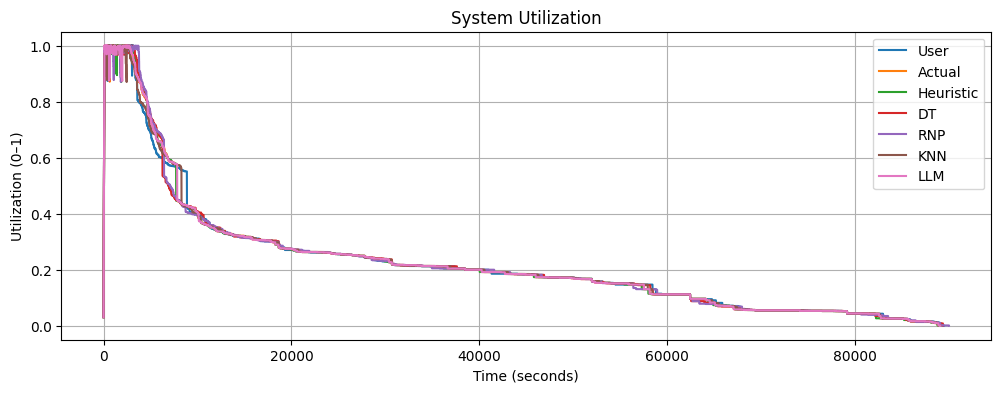

In [17]:
plot_metrics(metrics, labels)

Grafico salvato in: images/1800x980/sys_util_0_3600_M2.png


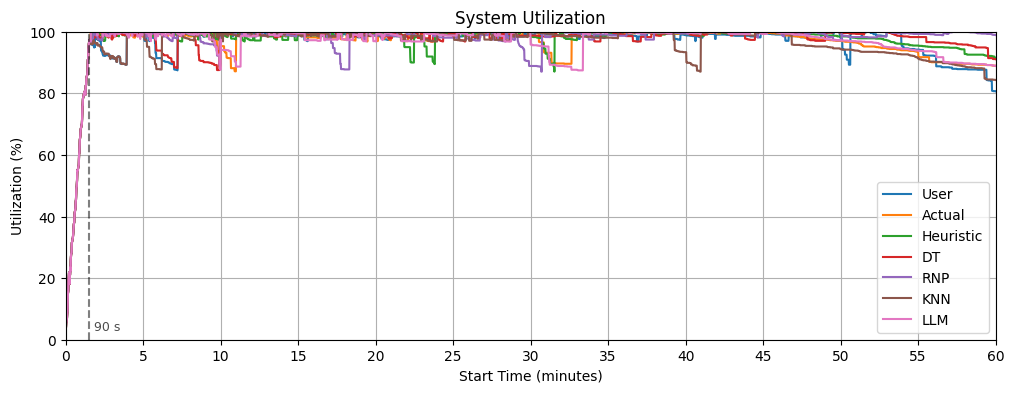

In [18]:
plot_metrics_window(metrics, labels, t_end=3601, v_lines=[90], image_path="images/1800x980/sys_util_0_3600_M2.png")

### System Metrics vs Prediction Error

Grafico salvato in: images/1800x980/metrics_vs_errors.png


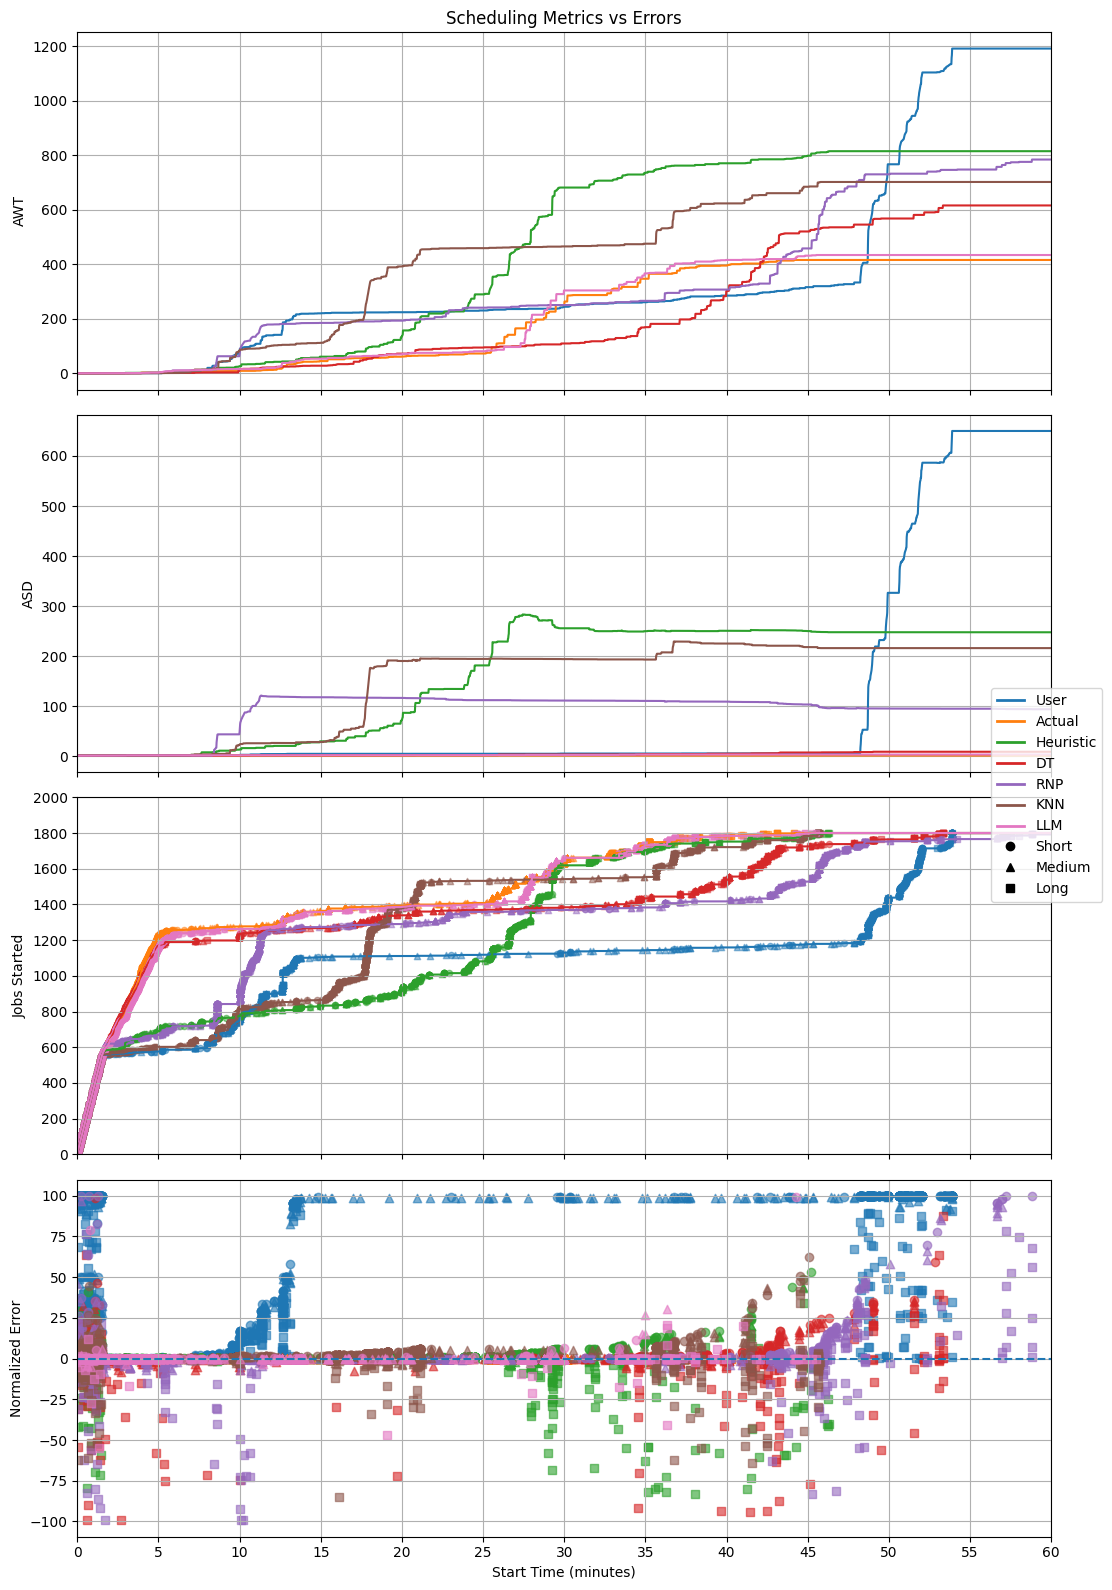

In [19]:
plot_metrics_with_errors(metrics, err_df, labels, image_path="images/1800x980/metrics_vs_errors.png")

### Job's Duration Class in Time-Window

In [20]:
t_w = [
    [0, 90], 
    [90, 390], 
    [480, 720], 
    [960, 1080], 
    [1440, 1740], 
    [2820, 3240]
]

Grafico salvato in: images/1800x980/job_count_vs_actual_combined.png


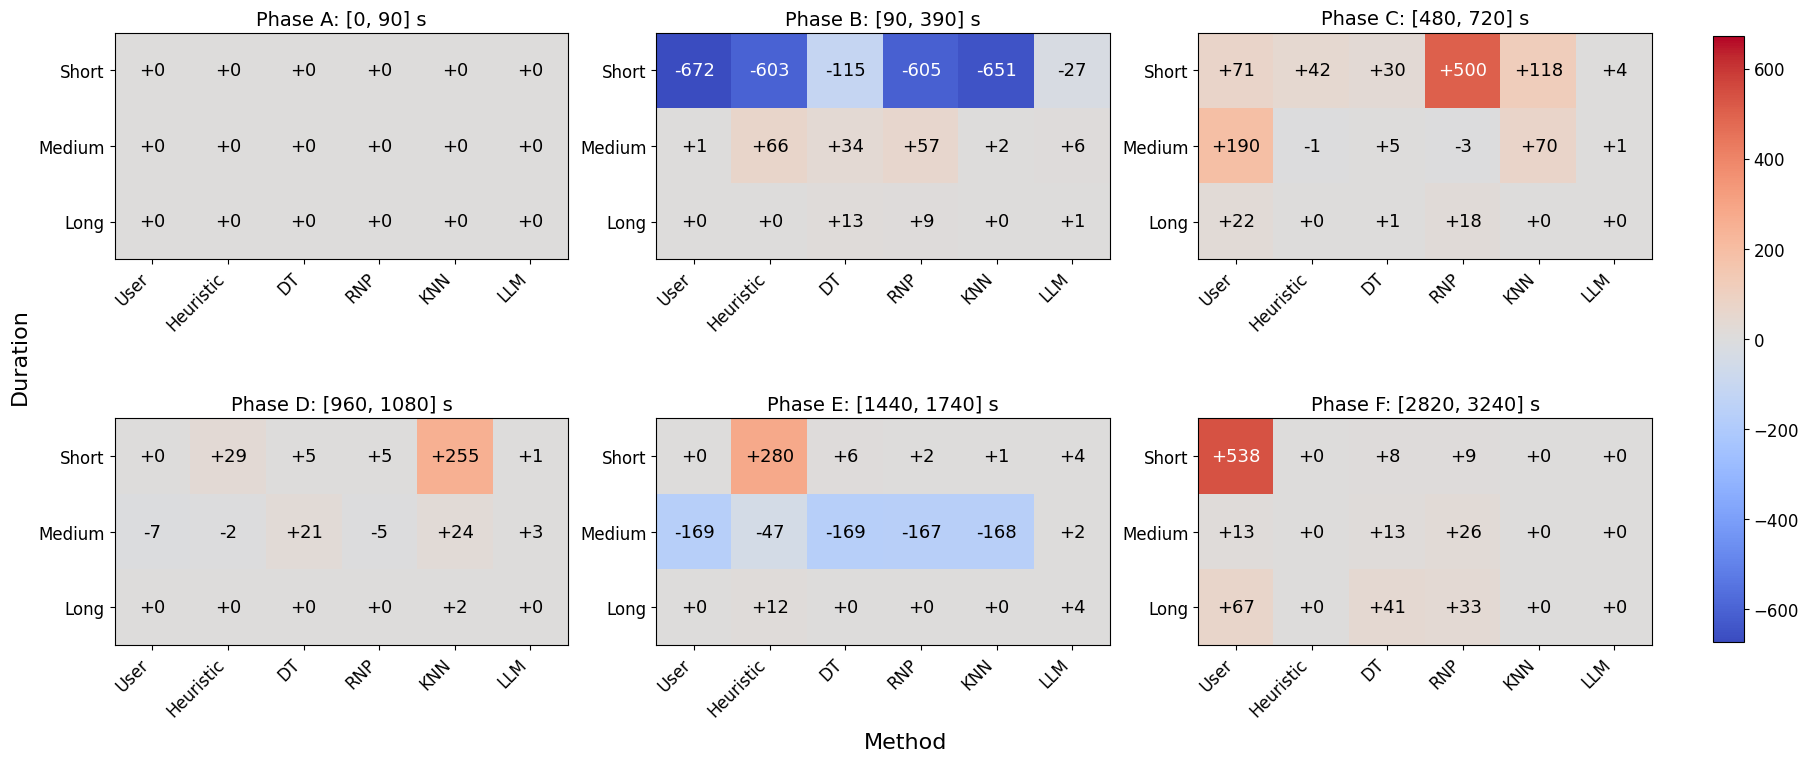

In [21]:
plot_duration_vs_methods_differences_multi(
    err_df,
    t_w,  
    image_path="images/1800x980/job_count_vs_actual_combined.png"
)

Grafico salvato in: images/1800x980/job_count_vs_actual_90_390.png


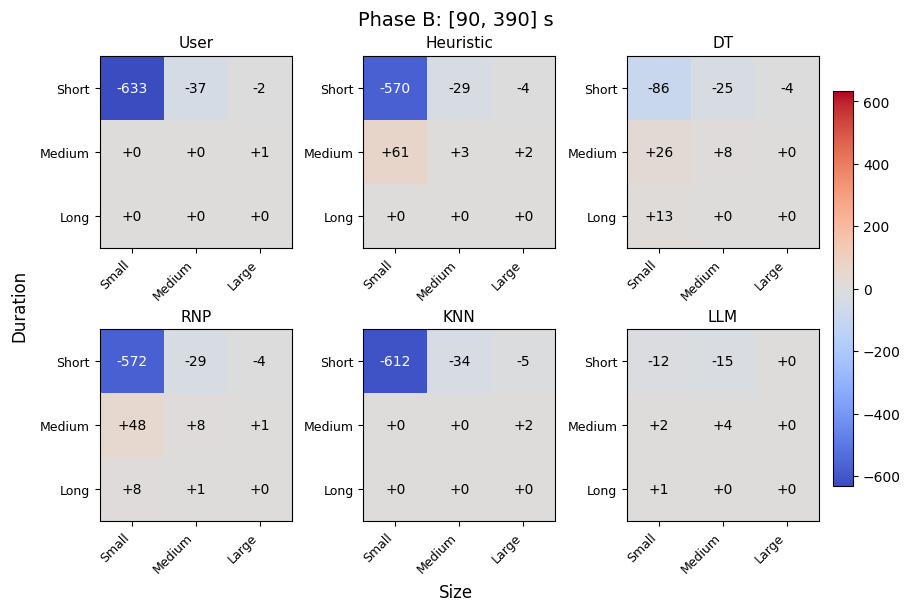

In [22]:
plot_job_class_matrix_differences(err_df, t_start=90, t_end=390, image_path="images/1800x980/job_count_vs_actual_90_390.png")

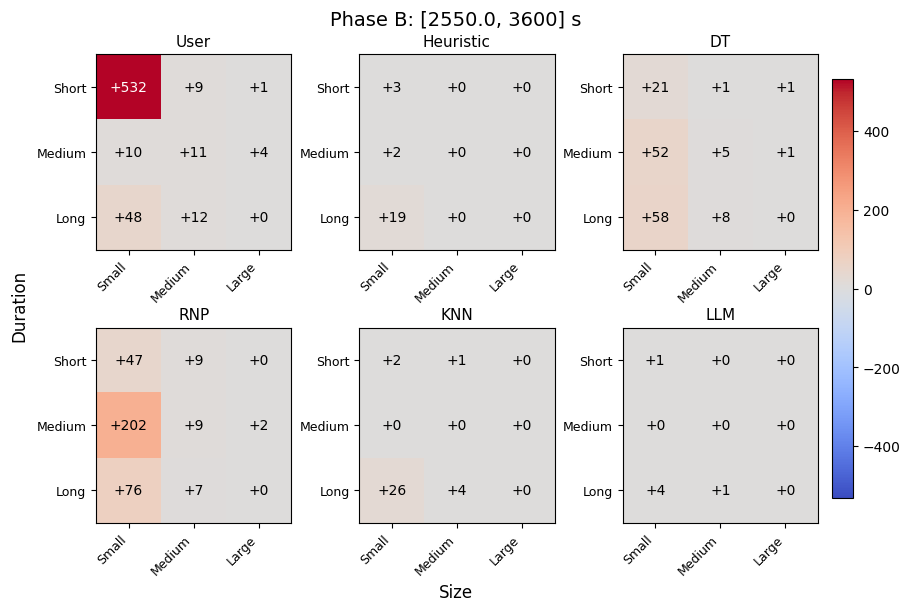

In [23]:
plot_job_class_matrix_differences(err_df, t_start=42.5*60, t_end=60*60)

### Critical Jobs

In [24]:
job_ids = []

filtered_workload = err_df[err_df.st_user.between(90,390)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_heuristic.between(90,390)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_rnp.between(90,390)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_knn.between(90,390)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

job_ids = list(set(job_ids))

In [25]:
methods = ["User", "Actual", "Heuristic", "RNP", "KNN"]
# methods = None

Grafico salvato in: images/1800x980/util_vs_critical_errors.png


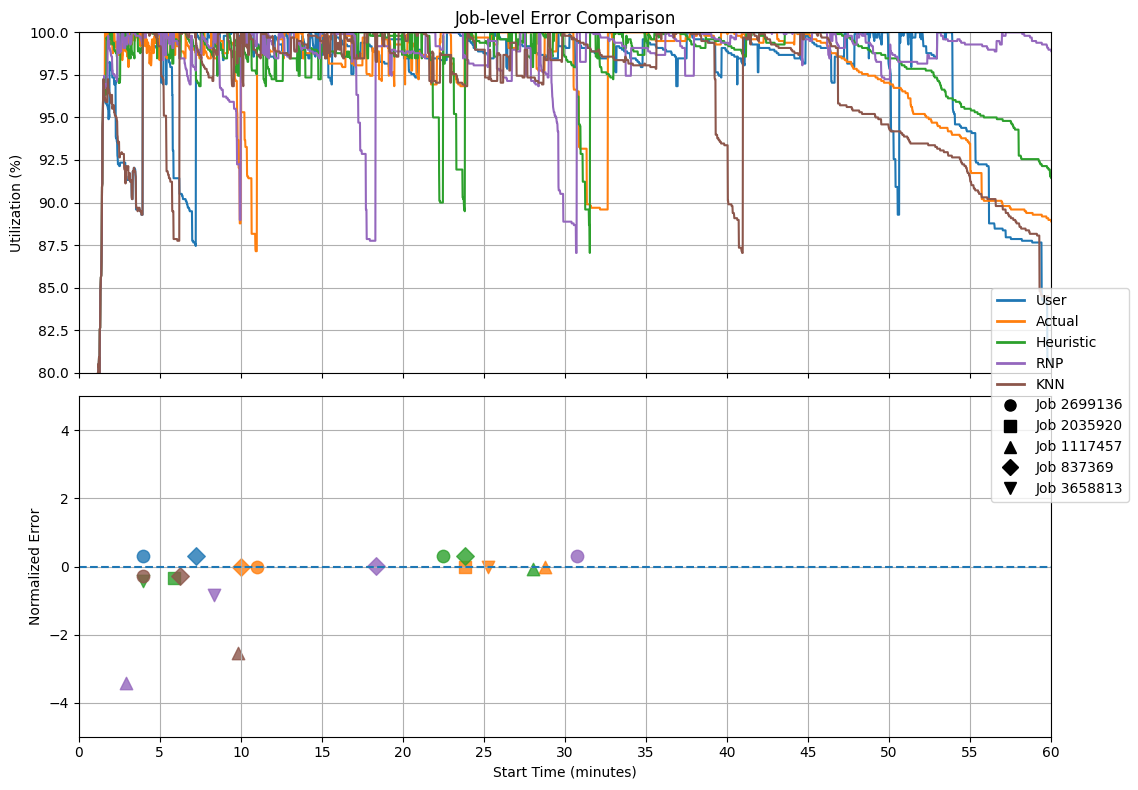

In [26]:
plot_job_errors_across_methods(
    metrics,
    err_df,
    labels,
    job_ids,
    methods_to_plot=methods,
    t_start=0,
    t_end=3900,
    error_window=(-5, 5),
    image_path="images/1800x980/util_vs_critical_errors.png"
)

In [27]:
workload_df[workload_df.job_id.isin(job_ids)]

,job_id,submit_time,Wait Time,Run Time,Number of Allocated Nodes,Average CPU Time Used,Used Memory,Requested Number of Nodes,Requested Time,Requested Memory,Status,User ID,Group ID,Executable Number,Queue Number,Partition Number,Preceding Job Number,Think Time from Preceding Job
560,2699136,93,25625,328,128,328,950,128,600,950,1,1040,25200,-1,-1,-1,-1,-1
678,1117457,113,133,2969,32,2969,7187,32,10800,7187,1,561,25200,-1,-1,-1,-1,-1
731,2035920,121,15498,643,32,643,7187,32,85800,7187,1,342,25200,-1,-1,-1,-1,-1
1036,3658813,172,99499,714,32,714,7187,32,86100,7187,1,342,25200,-1,-1,-1,-1,-1
1565,837369,260,29479,326,128,326,950,128,600,950,1,1040,25200,-1,-1,-1,-1,-1


In [28]:
err_df[err_df.job_id.isin(job_ids)]

,job_id,duration_class,size_class,st_user,err_user,st_actual,err_actual,st_heuristic,err_heuristic,st_dt,err_dt,st_rnp,err_rnp,st_knn,err_knn,st_llm,err_llm
571,2699136,Medium,Large,237,0.314815,660,0,1349,0.314815,596,-0.280093,1844,0.314815,237,-0.271991,678,0.000000
590,837369,Medium,Large,434,0.317130,600,0,1430,0.317130,924,-0.001157,1099,0.001157,373,-0.269676,600,0.000000
743,1117457,Medium,Large,596,9.063657,1725,0,1683,-0.069444,602,-3.202546,173,-3.435185,588,-2.549769,1725,0.000000
1107,2035920,Medium,Large,940,98.561343,1429,0,351,-0.347222,1257,-0.144676,3142,60.468750,2094,5.429398,1227,-0.027778
1185,3658813,Medium,Large,2872,98.826389,1514,0,237,-0.436343,2227,0.917824,499,-0.825231,1309,5.275463,1467,0.000000


In [29]:
predictions[predictions.job_id.isin(job_ids)]

,job_id,user_id,time_submit,gt_runtime,pred_runtime_user,pred_runtime_heuristic,pred_runtime_dt,pred_runtime_rnp,pred_runtime_knn,pred_runtime_llm,pred_runtime_knn_c4,pred_runtime_knn_c7
14443,1117457,561,12292999,2969,10800,2909,202,1,766,2969,Medium,Medium-Short
18601,3658813,342,12564628,714,86100,337,1507,1,5272,714,Short,Short
19596,2035920,342,12664976,643,85800,343,518,52888,5334,619,Medium,Short
63015,2699136,1040,13433788,328,600,600,86,600,93,328,Medium,Medium-Short
63063,837369,1040,13434878,326,600,600,325,327,93,326,Medium,Medium-Short


In [30]:
critical = err_df.merge(
    workload_df,
    on="job_id",
    how="left"
)

critical = critical.merge(
    predictions,
    on="job_id",
    how="left"
)

selected_columns = ["job_id", "submit_time", "Run Time", "Number of Allocated Nodes",
           "gt_runtime", "st_actual", 
           "pred_runtime_user", "st_user", 
           "pred_runtime_heuristic", "st_heuristic", 
           "pred_runtime_dt", "st_dt", 
           "pred_runtime_rnp", "st_rnp", 
           "pred_runtime_knn", "st_knn", 
           "pred_runtime_llm", "st_llm", 
          ]

column_names = ["Job ID", "Submit Time", "Runtime", "Number of Allocated Nodes",
           "Runtime (Actual)", "Start Time (Actual)", 
           "Runtime (User)", "Start Time (User)", 
           "Runtime (Heuristic)", "Start Time (Heuristic)", 
           "Runtime (DT)", "Start Time (DT)", 
           "Runtime (RNP)", "Start Time (RNP)", 
           "Runtime (KNN)", "Start Time (KNN)", 
           "Runtime (LLM)", "Start Time (LLM)", 
          ]

critical = critical[selected_columns]
critical = critical[critical.job_id.isin(job_ids)]
critical.columns = column_names
critical

,Job ID,Submit Time,Runtime,Number of Allocated Nodes,Runtime (Actual),Start Time (Actual),Runtime (User),Start Time (User),Runtime (Heuristic),Start Time (Heuristic),Runtime (DT),Start Time (DT),Runtime (RNP),Start Time (RNP),Runtime (KNN),Start Time (KNN),Runtime (LLM),Start Time (LLM)
571,2699136,93,328,128,328,660,600,237,600,1349,86,596,600,1844,93,237,328,678
590,837369,260,326,128,326,600,600,434,600,1430,325,924,327,1099,93,373,326,600
743,1117457,113,2969,32,2969,1725,10800,596,2909,1683,202,602,1,173,766,588,2969,1725
1107,2035920,121,643,32,643,1429,85800,940,343,351,518,1257,52888,3142,5334,2094,619,1227
1185,3658813,172,714,32,714,1514,86100,2872,337,237,1507,2227,1,499,5272,1309,714,1467


## Average System Utilization

In [31]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.22431428229296743
Actual    = 0.2255038640064185
Heuristic = 0.2255824350150976
DT        = 0.2246280963420623
RNP       = 0.22300330449843078
KNN       = 0.22528617908118023
LLM       = 0.22529882367387263


# Heavy 2

## System Metrics Computation

In [17]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_2.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")

# =========================================================
# DT
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)

df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")

# =========================================================
# RNP
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")

# =========================================================
# KNN
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")

# =========================================================
# LLM
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_2/pm100_1800_2_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [18]:
print(f'"OD_AWT_2": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_2": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_2": [26727212199.002853, 0, 23528390416.125767, 4218729905.316532, 13371963397.938272, 7830224779.977585, 254743077.61697954],
"OD_ASD_2": [303220071.99183744, 0, 105875954.70081319, 2709974.5674777715, 15738779.623845167, 49906339.245127976, 187500.96041153243]


## Merge metrics and errors

In [ ]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [ ]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

In [ ]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

In [ ]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [ ]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

# Heavy 3

## System Metrics Computation

In [19]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_3.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")

# =========================================================
# DT
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)

df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")

# =========================================================
# RNP
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")

# =========================================================
# KNN
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")

# =========================================================
# LLM
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_3/pm100_1800_3_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [20]:
print(f'"OD_AWT_3": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_3": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_3": [51359755831.86006, 0, 27993467534.338783, 11882636368.776566, 39196178057.98525, 18926011988.693882, 584800570.4677511],
"OD_ASD_3": [289397395.5542306, 0, 112286626.52068493, 8834758.651098523, 31345951.598691855, 67634160.65412682, 220982.44210402694]


## Merge metrics and errors

In [ ]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [ ]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

In [ ]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

In [ ]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [ ]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

# Heavy 4

## System Metrics Computation

In [21]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_4.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")

# =========================================================
# DT
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)

df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")

# =========================================================
# RNP
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")

# =========================================================
# KNN
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")

# =========================================================
# LLM
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_4/pm100_1800_4_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [22]:
print(f'"OD_AWT_4": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_4": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_4": [37416624885.72896, 0, 19172413584.143166, 6596908195.771634, 6967640049.436681, 11056367210.171545, 166368205.80202526],
"OD_ASD_4": [352487460.40068793, 0, 64448289.07533162, 5398365.321287194, 11695000.541776784, 53748677.803142205, 118576.70104696388]


## Merge metrics and errors

In [ ]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [ ]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

In [ ]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

In [ ]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [ ]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

# Heavy 5

## System Metrics Computation

In [23]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_5.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")

# =========================================================
# DT
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)

df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")

# =========================================================
# RNP
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")

# =========================================================
# KNN
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")

# =========================================================
# LLM
# =========================================================

filepath = 'queues/pm100/1800x980/heavy_5/pm100_1800_5_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [24]:
print(f'"OD_AWT_5": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_5": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_5": [36480936298.09854, 0, 19632388805.11136, 12580093882.551453, 32609105768.00629, 15367018062.557436, 816414121.7280858],
"OD_ASD_5": [264204191.04294497, 0, 71196716.75818971, 6580366.701678407, 27004054.32909537, 72322911.41773899, 380501.07551313605]


## Merge metrics and errors

In [ ]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [ ]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

In [ ]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

In [ ]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [ ]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])